STUDENT PLACEMENT DATASET
   CGPA  AptitudeScore  TechnicalScore  CommunicationScore Internship Branch  \
0   6.2             45              40                  50         No    CSE   
1   6.5             50              45                  52         No    ECE   
2   6.8             52              48                  55         No    CSE   
3   7.0             55              52                  58        Yes     IT   
4   7.2             58              55                  60         No    ECE   

  PlacementStatus CGPA_Tier  
0      Not Placed       Low  
1      Not Placed       Low  
2      Not Placed       Low  
3          Placed    Medium  
4      Not Placed    Medium  

Dataset Shape:
(30, 8)

CGPA Tier Distribution:
CGPA_Tier
High      13
Medium    10
Low        7
Name: count, dtype: int64

MISSING VALUE CHECK
CGPA                  0
AptitudeScore         0
TechnicalScore        0
CommunicationScore    0
Internship            0
Branch                0
PlacementStatus       0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Train Accuracy: 1.0
Validation Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         2
      Placed       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



MODEL COMPARISON
                           Train Accuracy  Validation Accuracy
Logistic Regression C=1          1.000000             1.000000
Logistic Regression C=0.1        0.958333             0.833333
Logistic Regression C=10         1.000000             1.000000


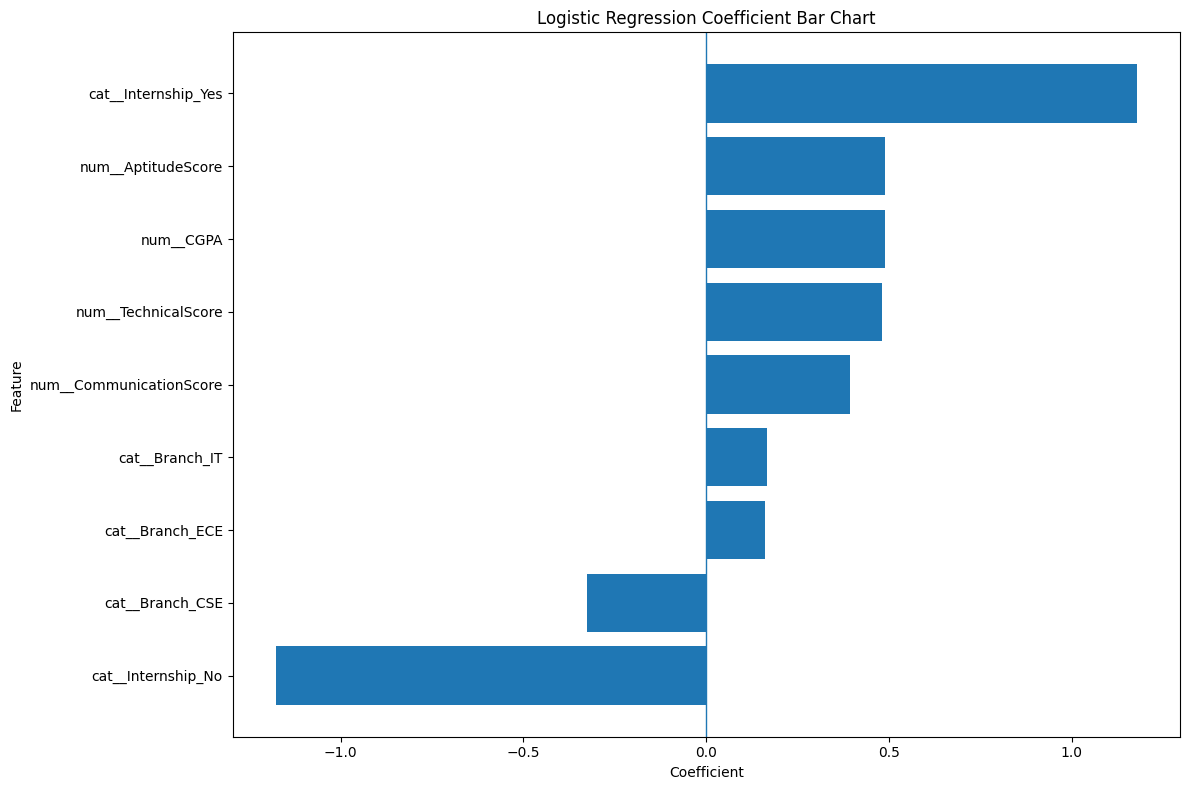



PRACTICAL CONCLUSION

1. A student placement dataset was created directly in Colab.

2. Numerical features were standardized using StandardScaler.

3. Categorical features were converted using One-Hot Encoding.

4. A Binary Logistic Regression model was used to predict
   PlacementStatus.

5. A Multinomial Logistic Regression model was used to predict
   CGPA_Tier.

6. The evaluate_classifier() function was created to calculate
   training accuracy, validation accuracy and classification report.

7. Three Logistic Regression models were evaluated.

8. Logistic Regression coefficients were displayed using
   a coefficient bar chart.

9. Accuracy, precision, recall and F1-score were used to
   evaluate classification performance.

ML SESSION 4 PRACTICAL COMPLETED


In [15]:
# ================================================================
# MACHINE LEARNING PRACTICAL - SESSION 4
# Topic:
# OHE + Scaling Pipeline
# Binary Logistic Regression - PlacementStatus
# Multinomial Logistic Regression - CGPA_Tier
# Coefficient Bar Chart
# evaluate_classifier() Function
# ================================================================


# ----------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ----------------------------------------------------------------
# pandas       -> Used for creating and handling the dataset
# numpy        -> Used for numerical operations
# matplotlib   -> Used for creating graphs
# sklearn      -> Used for Machine Learning algorithms
# ----------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report


# ----------------------------------------------------------------
# 2. CREATE A SMALL STUDENT PLACEMENT DATASET
# ----------------------------------------------------------------
# We are NOT using an external dataset.
# The dataset is created directly inside Google Colab.
#
# Features:
# CGPA                 -> Student CGPA
# AptitudeScore        -> Aptitude test score
# TechnicalScore       -> Technical test score
# CommunicationScore   -> Communication score
# Internship           -> Whether student has internship experience
# Branch               -> Student branch
#
# Targets:
# PlacementStatus      -> Binary classification target
# CGPA_Tier             -> Multiclass classification target
# ----------------------------------------------------------------

data = {

    'CGPA': [
        6.2, 6.5, 6.8, 7.0, 7.2,
        7.4, 7.6, 7.8, 8.0, 8.2,
        8.4, 8.6, 8.8, 9.0, 9.2,
        9.4, 6.1, 6.7, 7.1, 7.5,
        7.9, 8.3, 8.7, 9.1, 6.4,
        6.9, 7.3, 7.7, 8.1, 8.5
    ],

    'AptitudeScore': [
        45, 50, 52, 55, 58,
        60, 62, 65, 68, 70,
        72, 75, 78, 80, 85,
        88, 42, 48, 56, 61,
        67, 73, 77, 83, 46,
        54, 59, 64, 71, 76
    ],

    'TechnicalScore': [
        40, 45, 48, 52, 55,
        58, 60, 64, 67, 70,
        72, 76, 79, 82, 86,
        90, 38, 44, 50, 57,
        63, 69, 75, 84, 43,
        49, 55, 62, 68, 74
    ],

    'CommunicationScore': [
        50, 52, 55, 58, 60,
        62, 65, 67, 70, 72,
        74, 76, 79, 82, 85,
        88, 48, 54, 57, 61,
        64, 68, 73, 80, 51,
        56, 59, 63, 69, 75
    ],

    'Internship': [
        'No', 'No', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'No', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No', 'No', 'No', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'No',
        'No', 'Yes', 'Yes', 'Yes', 'Yes'
    ],

    'Branch': [
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'CSE',
        'IT', 'CSE', 'ECE', 'CSE', 'IT',
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'IT',
        'CSE', 'ECE', 'IT', 'CSE', 'CSE'
    ],

    # Binary target variable
    # Only TWO classes: Placed / Not Placed

    'PlacementStatus': [
        'Not Placed', 'Not Placed', 'Not Placed', 'Placed', 'Not Placed',
        'Placed', 'Placed', 'Not Placed', 'Placed', 'Placed',
        'Placed', 'Placed', 'Placed', 'Placed', 'Placed',
        'Placed', 'Not Placed', 'Not Placed', 'Not Placed', 'Placed',
        'Placed', 'Placed', 'Placed', 'Placed', 'Not Placed',
        'Not Placed', 'Placed', 'Placed', 'Placed', 'Placed'
    ]
}


# Convert dictionary into a Pandas DataFrame
df = pd.DataFrame(data)


# ----------------------------------------------------------------
# 3. CREATE CGPA_Tier
# ----------------------------------------------------------------
# CGPA_Tier is our MULTINOMIAL classification target.
#
# Low    -> CGPA below 7
# Medium -> CGPA from 7 to below 8
# High   -> CGPA 8 or above
#
# There are THREE classes, so this is a multiclass problem.
# ----------------------------------------------------------------

def create_cgpa_tier(cgpa):

    if cgpa < 7:
        return 'Low'

    elif cgpa < 8:
        return 'Medium'

    else:
        return 'High'


df['CGPA_Tier'] = df['CGPA'].apply(create_cgpa_tier)


# ----------------------------------------------------------------
# 4. DISPLAY THE DATASET
# ----------------------------------------------------------------

print("=" * 70)
print("STUDENT PLACEMENT DATASET")
print("=" * 70)

print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nCGPA Tier Distribution:")
print(df['CGPA_Tier'].value_counts())


# ----------------------------------------------------------------
# 5. CHECK FOR MISSING VALUES
# ----------------------------------------------------------------
# Missing values can cause problems during model training.
# Here we check whether any values are missing.
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

print(df.isnull().sum())


# ----------------------------------------------------------------
# 6. SEPARATE FEATURES AND TARGETS
# ----------------------------------------------------------------
#
# X -> Input features used for prediction
#
# y_binary -> PlacementStatus
#             Two classes:
#             Placed / Not Placed
#
# y_multi -> CGPA_Tier
#            Three classes:
#            Low / Medium / High
# ----------------------------------------------------------------

X = df.drop(
    columns=['PlacementStatus', 'CGPA_Tier']
)

y_binary = df['PlacementStatus']

y_multi = df['CGPA_Tier']


# ----------------------------------------------------------------
# 7. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ----------------------------------------------------------------
#
# Numerical:
# CGPA
# AptitudeScore
# TechnicalScore
# CommunicationScore
#
# Categorical:
# Internship
# Branch
# ----------------------------------------------------------------

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()


print("\n" + "=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)


# ----------------------------------------------------------------
# 8. CREATE OHE + SCALING PIPELINE
# ----------------------------------------------------------------
#
# OHE = One-Hot Encoding
#
# It converts categorical data into numerical columns.
#
# Example:
#
# Branch:
# CSE
# ECE
# IT
#
# becomes:
#
# Branch_CSE
# Branch_ECE
# Branch_IT
#
#
# StandardScaler:
# Standardizes numerical features so that they are
# approximately on the same scale.
# ----------------------------------------------------------------

preprocessor = ColumnTransformer(

    transformers=[

        # Scale numerical columns
        ('num',
         StandardScaler(),
         numerical_cols),

        # Convert categorical columns to numerical form
        ('cat',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_cols)
    ]
)


print("\nOHE + SCALING PIPELINE CREATED SUCCESSFULLY.")


# =================================================================
# 9. BINARY LOGISTIC REGRESSION
# =================================================================
#
# Logistic Regression is a classification algorithm.
#
# Binary classification means there are TWO possible classes.
#
# Here:
#
# Placed
# Not Placed
#
# The model predicts whether a student will be placed.
# =================================================================


# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(

    X,
    y_binary,

    test_size=0.2,

    random_state=42,

    stratify=y_binary
)


# Create the complete ML pipeline
binary_model = Pipeline([

    # First perform OHE + Scaling
    ('preprocessor', preprocessor),

    # Then apply Logistic Regression
    ('classifier',
     LogisticRegression(max_iter=1000))
])


# Train the model
binary_model.fit(
    X_train,
    y_train
)


# Predict training data
train_pred = binary_model.predict(
    X_train
)


# Predict validation data
val_pred = binary_model.predict(
    X_val
)


# Calculate accuracy
train_accuracy = accuracy_score(
    y_train,
    train_pred
)

val_accuracy = accuracy_score(
    y_val,
    val_pred
)


print("\n" + "=" * 70)
print("BINARY LOGISTIC REGRESSION - PLACEMENT STATUS")
print("=" * 70)

print("Train Accuracy:",
      train_accuracy)

print("Validation Accuracy:",
      val_accuracy)


print("\nClassification Report:")

print(
    classification_report(
        y_val,
        val_pred
    )
)


# =================================================================
# 10. MULTINOMIAL LOGISTIC REGRESSION
# =================================================================
#
# Multinomial classification means there are MORE THAN TWO classes.
#
# Our target:
#
# Low
# Medium
# High
#
# Therefore CGPA_Tier is a multiclass classification problem.
# =================================================================


# Split data
X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(

    X,
    y_multi,

    test_size=0.2,

    random_state=42,

    stratify=y_multi
)


# Create Multinomial Logistic Regression pipeline
multi_model = Pipeline([

    # OHE + Scaling
    ('preprocessor', preprocessor),

    # Logistic Regression
    ('classifier',
     LogisticRegression(max_iter=1000))
])


# Train model
multi_model.fit(
    X_train_m,
    y_train_m
)


# Predictions
train_pred_m = multi_model.predict(
    X_train_m
)

val_pred_m = multi_model.predict(
    X_val_m
)


# Accuracy
train_accuracy_m = accuracy_score(
    y_train_m,
    train_pred_m
)

val_accuracy_m = accuracy_score(
    y_val_m,
    val_pred_m
)


print("\n" + "=" * 70)
print("MULTINOMIAL LOGISTIC REGRESSION - CGPA TIER")
print("=" * 70)

print("Train Accuracy:",
      train_accuracy_m)

print("Validation Accuracy:",
      val_accuracy_m)


print("\nClassification Report:")

print(
    classification_report(
        y_val_m,
        val_pred_m
    )
)


# =================================================================
# 11. EVALUATE_CLASSIFIER() FUNCTION
# =================================================================
#
# This function:
#
# 1. Fits the model
# 2. Predicts training data
# 3. Predicts validation data
# 4. Calculates training accuracy
# 5. Calculates validation accuracy
# 6. Prints classification report
#
# This avoids writing the same code repeatedly.
# =================================================================


def evaluate_classifier(
    model,
    X_train,
    y_train,
    X_val,
    y_val
):

    # Train the model
    model.fit(
        X_train,
        y_train
    )


    # Training prediction
    train_prediction = model.predict(
        X_train
    )


    # Validation prediction
    val_prediction = model.predict(
        X_val
    )


    # Calculate training accuracy
    train_accuracy = accuracy_score(
        y_train,
        train_prediction
    )


    # Calculate validation accuracy
    val_accuracy = accuracy_score(
        y_val,
        val_prediction
    )


    print("Train Accuracy:",
          train_accuracy)

    print(
        "Validation Accuracy:",
        val_accuracy
    )


    print("\nClassification Report:")

    print(
        classification_report(
            y_val,
            val_prediction
        )
    )


    # Return both accuracy values
    return train_accuracy, val_accuracy


# =================================================================
# 12. CREATE THREE LOGISTIC REGRESSION MODELS
# =================================================================
#
# We use different C values.
#
# C controls the regularization strength.
#
# C = 0.1 -> stronger regularization
# C = 1   -> normal/default setting
# C = 10  -> weaker regularization
# =================================================================


models = {

    "Logistic Regression C=1": Pipeline([

        ('preprocessor',
         preprocessor),

        ('classifier',
         LogisticRegression(
             C=1,
             max_iter=1000
         ))
    ]),


    "Logistic Regression C=0.1": Pipeline([

        ('preprocessor',
         preprocessor),

        ('classifier',
         LogisticRegression(
             C=0.1,
             max_iter=1000
         ))
    ]),


    "Logistic Regression C=10": Pipeline([

        ('preprocessor',
         preprocessor),

        ('classifier',
         LogisticRegression(
             C=10,
             max_iter=1000
         ))
    ])
}


# =================================================================
# 13. EVALUATE ALL THREE MODELS
# =================================================================

results = {}


for name, model in models.items():

    print("\n")
    print("=" * 70)
    print(name)
    print("=" * 70)


    train_acc, val_acc = evaluate_classifier(

        model,

        X_train,
        y_train,

        X_val,
        y_val
    )


    # Store results
    results[name] = {

        'Train Accuracy':
        train_acc,

        'Validation Accuracy':
        val_acc
    }


# =================================================================
# 14. DISPLAY MODEL COMPARISON
# =================================================================

results_df = pd.DataFrame(
    results
).T


print("\n")
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(results_df)


# =================================================================
# 15. COEFFICIENT BAR CHART
# =================================================================
#
# Logistic Regression assigns coefficients to features.
#
# Positive coefficient:
# Associated with higher log-odds for the modeled class.
#
# Negative coefficient:
# Associated with lower log-odds for the modeled class.
#
# We visualize the coefficients using a bar chart.
# =================================================================


# Train the binary model again
binary_model.fit(
    X_train,
    y_train
)


# Get names of features after OHE
feature_names = (
    binary_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)


# Get Logistic Regression coefficients
coefficients = (
    binary_model
    .named_steps['classifier']
    .coef_[0]
)


# Create DataFrame
coef_df = pd.DataFrame({

    'Feature':
    feature_names,

    'Coefficient':
    coefficients
})


# Sort coefficients
coef_df = coef_df.sort_values(
    by='Coefficient'
)


# =================================================================
# 16. PLOT COEFFICIENT BAR CHART
# =================================================================

plt.figure(
    figsize=(12, 8)
)


plt.barh(

    coef_df['Feature'],

    coef_df['Coefficient']
)


plt.xlabel(
    'Coefficient'
)


plt.ylabel(
    'Feature'
)


plt.title(
    'Logistic Regression Coefficient Bar Chart'
)


plt.axvline(
    0,
    linewidth=1
)


plt.tight_layout()


plt.show()


# =================================================================
# 17. FINAL SUMMARY
# =================================================================

print("\n")
print("=" * 70)
print("PRACTICAL CONCLUSION")
print("=" * 70)

print("""
1. A student placement dataset was created directly in Colab.

2. Numerical features were standardized using StandardScaler.

3. Categorical features were converted using One-Hot Encoding.

4. A Binary Logistic Regression model was used to predict
   PlacementStatus.

5. A Multinomial Logistic Regression model was used to predict
   CGPA_Tier.

6. The evaluate_classifier() function was created to calculate
   training accuracy, validation accuracy and classification report.

7. Three Logistic Regression models were evaluated.

8. Logistic Regression coefficients were displayed using
   a coefficient bar chart.

9. Accuracy, precision, recall and F1-score were used to
   evaluate classification performance.
""")

print("=" * 70)
print("ML SESSION 4 PRACTICAL COMPLETED")
print("=" * 70)